In [5]:
import pandas as pd

df = pd.read_csv('/content/HistoricalQuotes.csv')

# Column names clean karo
df.columns = df.columns.str.strip()

# Date convert karo
df['Date'] = pd.to_datetime(df['Date'])

# Dollar sign remove karo
df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)
df['Open'] = df['Open'].replace('[\$,]', '', regex=True).astype(float)
df['High'] = df['High'].replace('[\$,]', '', regex=True).astype(float)
df['Low'] = df['Low'].replace('[\$,]', '', regex=True).astype(float)

df.head()

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_1688/2161695825.py:12: SyntaxWarning: invalid escape sequence '\$'
  df['Close/Last'] = df['Close/Last'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_1688/2161695825.py:13: SyntaxWarning: invalid escape sequence '\$'
  df['Open'] = df['Open'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_1688/2161695825.py:14: SyntaxWarning: invalid escape sequence '\$'
  df['High'] = df['High'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipykernel_1688/2161695825.py:15: SyntaxWarning: invalid escape sequence '\$'
  df['Low'] = df['Low'].replace('

,Date,Close/Last,Volume,Open,High,Low
0,2020-02-28,273.36,106721200,257.26,278.41,256.37
1,2020-02-27,273.52,80151380,281.10,286.00,272.96
2,2020-02-26,292.65,49678430,286.53,297.88,286.50
3,2020-02-25,288.08,57668360,300.95,302.53,286.13
4,2020-02-24,298.18,55548830,297.26,304.18,289.23


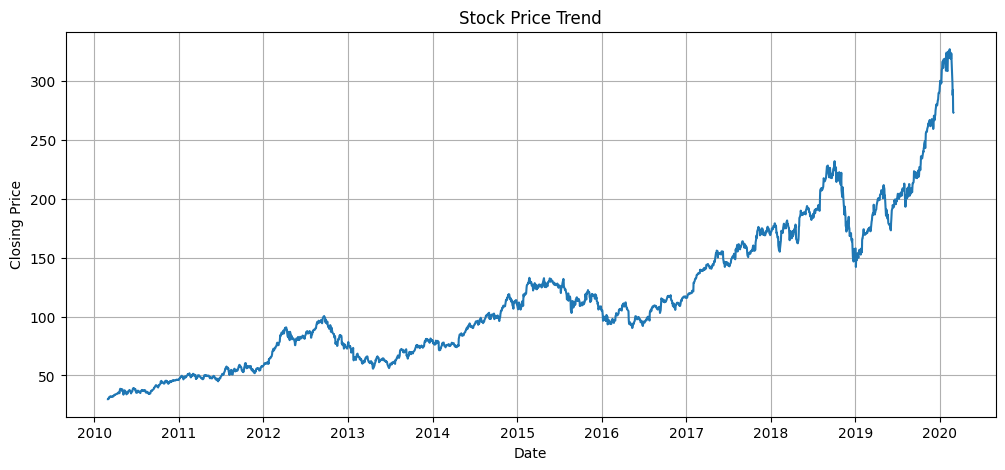

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close/Last'])

plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

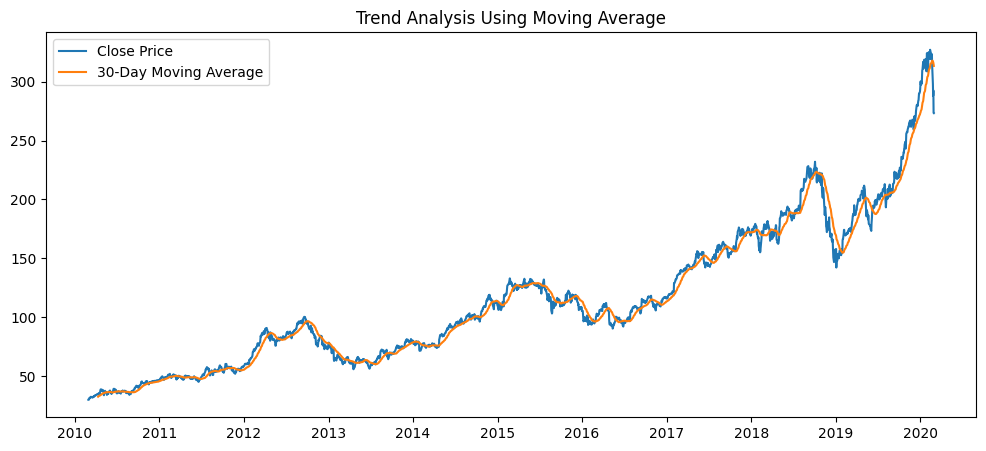

In [7]:
df = df.sort_values('Date')

df['MA30'] = df['Close/Last'].rolling(30).mean()

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Close/Last'], label='Close Price')
plt.plot(df['Date'], df['MA30'], label='30-Day Moving Average')

plt.legend()
plt.title("Trend Analysis Using Moving Average")

plt.show()

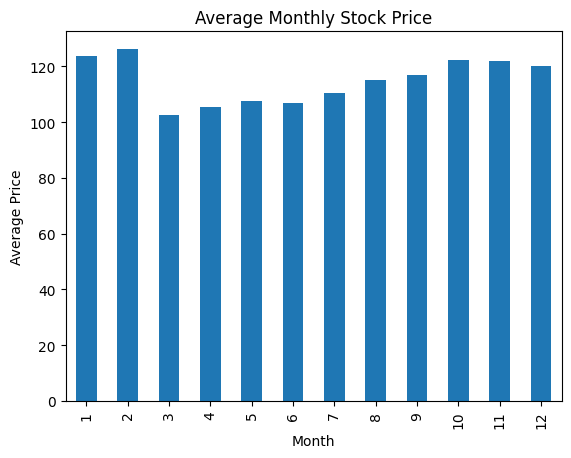

In [8]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Close/Last'].mean()

monthly_avg.plot(kind='bar')

plt.title("Average Monthly Stock Price")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

In [9]:
from sklearn.linear_model import LinearRegression
import numpy as np

df = df.sort_values('Date')

df['Day'] = np.arange(len(df))

X = df[['Day']]
y = df['Close/Last']

model = LinearRegression()
model.fit(X, y)

future_days = np.arange(
    len(df),
    len(df)+30
).reshape(-1,1)

future_prices = model.predict(future_days)

print("Next 30 Day Forecast:")
print(future_prices)

Next 30 Day Forecast:
[211.27334636 211.3499671  211.42658784 211.50320858 211.57982933
 211.65645007 211.73307081 211.80969155 211.88631229 211.96293303
 212.03955378 212.11617452 212.19279526 212.269416   212.34603674
 212.42265748 212.49927823 212.57589897 212.65251971 212.72914045
 212.80576119 212.88238193 212.95900268 213.03562342 213.11224416
 213.1888649  213.26548564 213.34210638 213.41872713 213.49534787]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
